<a href="https://colab.research.google.com/github/BimalGhimire38/Extra_Python_Stuffs/blob/main/PyTorch_Autograd_Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2082/12/11 09:17 PM

# Background

In [2]:
def dy_dx(x):
  return 2*x

In [3]:
dy_dx(3)

6

In [6]:
import math

def dz_dx(x):
  return 2*x*math.cos(x**2)

In [7]:
dz_dx(5)

9.912028118634735

# Using Autograd

In [8]:
import torch

In [9]:
x = torch.tensor(3.0, requires_grad=True)

In [10]:
y = x**2

In [13]:
x

tensor(3., requires_grad=True)

In [14]:
y

tensor(9., grad_fn=<PowBackward0>)

In [15]:
y.backward()

In [16]:
x.grad

tensor(6.)

New Example

In [18]:
x=torch.tensor(3.0, requires_grad=True)

In [19]:
y = x**2

In [20]:
z=torch.sin(y)

In [21]:
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [22]:
y

tensor(9., grad_fn=<PowBackward0>)

In [23]:
z.backward()

In [24]:
x.grad

tensor(-5.4668)

In [25]:
y.grad

/tmp/ipykernel_181/486760323.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  y.grad


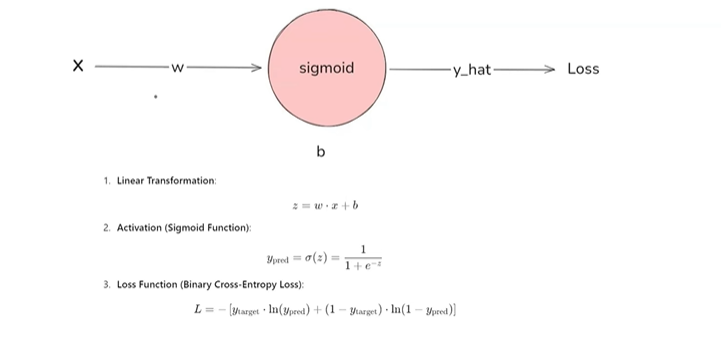

# Manual Method

In [26]:
# Inputs
x=torch.tensor(6.7)
y=torch.tensor(0.0)

w=torch.tensor(1.0) # Weight
b=torch.tensor(0.0)  # Bias

In [27]:
#  Binary Cross Entropy Loss for Scalar
def binary_cross_entropy_loss(prediction, target):
  epsilon = 1e-8 #  To prevent log(0)
  prediction = torch.clamp(prediction, epsilon, 1-epsilon)
  return -(target*torch.log(prediction)+(1-target)*torch.log(1-prediction))

In [28]:
# Forward Pass
z=w*x+b
y_pred = torch.sigmoid(z)

loss = binary_cross_entropy_loss(y_pred, y)

In [30]:
loss

tensor(6.7012)

In [29]:
# Derivatives

In [32]:
# 1.
dloss_dy_pred = (y_pred-y)/(y_pred*(1-y_pred))

dy_pred_dz = y_pred*(1-y_pred)

dz_dw = x
dz_db=1

dl_dw = dloss_dy_pred*dy_pred_dz*dz_dw
dl_db = dloss_dy_pred*dy_pred_dz*dz_db

In [33]:
print(f"manual Gradient of loss wrt w is{dl_dw}")
print(f"manual Gradient of loss wrt b is{dl_db}")

manual Gradient of loss wrt w is6.691762447357178
manual Gradient of loss wrt b is0.998770534992218


# Autograd Method

In [34]:
x = torch.tensor(6.7)
y = torch.tensor(0.0)

In [35]:
w = torch.tensor(1.0, requires_grad = True)
b = torch.tensor(0.0, requires_grad = True)

In [36]:
z = w*x+b

In [38]:
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [39]:
y_pred = torch.sigmoid(z)

In [40]:
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [41]:
loss = binary_cross_entropy_loss(y_pred, y)

In [42]:
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [43]:
loss.backward()

In [45]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


# Vector input tensors

In [46]:
x= torch.tensor([1.0,2.0,3.0], requires_grad = True)

In [47]:
x

tensor([1., 2., 3.], requires_grad=True)

In [48]:
y=(x**2).mean()

In [49]:
y

tensor(4.6667, grad_fn=<MeanBackward0>)

In [50]:
y.backward()

In [51]:
x.grad

tensor([0.6667, 1.3333, 2.0000])

# Clearing Grads

In [58]:
x = torch.tensor(2., requires_grad=True)

In [80]:
x

tensor(2., requires_grad=True)

In [81]:
y = x**2

In [82]:
y

tensor(4., grad_fn=<PowBackward0>)

In [83]:
y.backward()

In [84]:
x.grad

tensor(4.)

In [85]:
x.grad.zero_()

tensor(0.)

# Turning Gradient Tracking Off

In [86]:
# option 1 - requires_grad_(False)
# option 2 - detach()
# option 3 - torch.no_grad()

### Requires Grad False

In [87]:
x.requires_grad_(False)

tensor(2.)

In [88]:
x

tensor(2.)

In [89]:
y = x**2

In [90]:
y

tensor(4.)

### Detach

In [94]:
x = torch.tensor(1.5, requires_grad=True)

In [95]:
z = x.detach()

In [96]:
print(x,z)

tensor(1.5000, requires_grad=True) tensor(1.5000)


### Torch.no_grad()

In [98]:
with torch.no_grad():
  y = x** 2

In [99]:
y

tensor(2.2500)

In [100]:
x

tensor(1.5000, requires_grad=True)